# 06 · Dataset Preparation  (FDR Section 2)

How the behavior data was sourced, labelled, focused, balanced and split.

**Source.** Open-source *Distracted Driving* dataset (Roboflow Universe,
`ipylot-project/distracted-driving-v2wk5`, v7) — 8,865 labelled images, 13
activity classes. Per the competition rules, open-source datasets may be used for
training/fine-tuning, reserving the competition clips for qualitative validation.

**Focusing.** QuisMotion only needs *phone use* vs *safe*. The 13 classes diluted
the signal (and the original split left only 3 phone boxes in test). We therefore
**remapped** `Texting`+`Talking on the phone` → `phone`, `Safe Driving` → `safe`,
dropped the rest, and **re-stratified** into a balanced 70/15/15 split.

In [1]:
%matplotlib inline
import glob, os
import matplotlib.pyplot as plt
DS = "../tmp/behavior_ds"
NAMES = ["phone","safe"]
counts = {s:{0:0,1:0} for s in ["train","valid","test"]}
imgs   = {s:0 for s in ["train","valid","test"]}
for s in counts:
    for lbl in glob.glob(f"{DS}/{s}/labels/*.txt"):
        imgs[s]+=1
        for ln in open(lbl):
            if ln.strip(): counts[s][int(ln.split()[0])]+=1
tot = sum(imgs.values())
print(f"{'split':7}{'images':>8}{'phone':>8}{'safe':>8}{'ratio':>8}")
for s in ["train","valid","test"]:
    print(f"{s:7}{imgs[s]:>8}{counts[s][0]:>8}{counts[s][1]:>8}{imgs[s]/tot:>7.0%}")
print(f"{'TOTAL':7}{tot:>8}")

split    images   phone    safe   ratio
train      2224    1398     826    70%
valid       477     300     177    15%
test        478     300     178    15%
TOTAL      3179


**Class distribution per split** (balanced — phone present in every split).

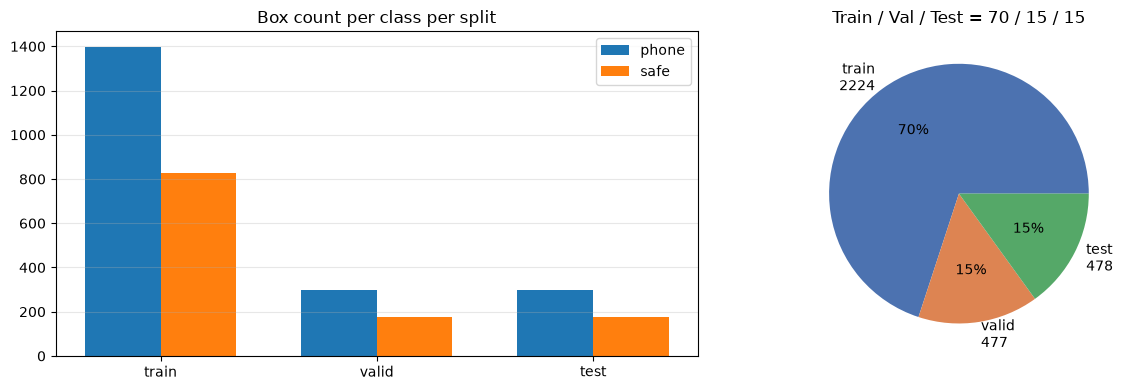

In [2]:
import numpy as np
splits=["train","valid","test"]; x=np.arange(len(splits)); w=0.35
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].bar(x-w/2,[counts[s][0] for s in splits],w,label="phone")
ax[0].bar(x+w/2,[counts[s][1] for s in splits],w,label="safe")
ax[0].set_xticks(x); ax[0].set_xticklabels(splits); ax[0].set_title("Box count per class per split"); ax[0].legend(); ax[0].grid(alpha=.3,axis="y")
ax[1].pie([imgs[s] for s in splits],labels=[f"{s}\n{imgs[s]}" for s in splits],autopct="%1.0f%%",colors=["#4c72b0","#dd8452","#55a868"])
ax[1].set_title("Train / Val / Test = 70 / 15 / 15")
plt.tight_layout(); plt.show()

**Split justification.** 70/15/15 is a standard partition that leaves enough data
to train while keeping statistically meaningful, **class-balanced** validation and
test sets. Stratifying by class guarantees `phone` and `safe` both appear in every
split (the original vendor split did not — it had only 3 phone boxes in test, which
made the phone metric meaningless).

**Data augmentation** (applied during training to improve robustness).

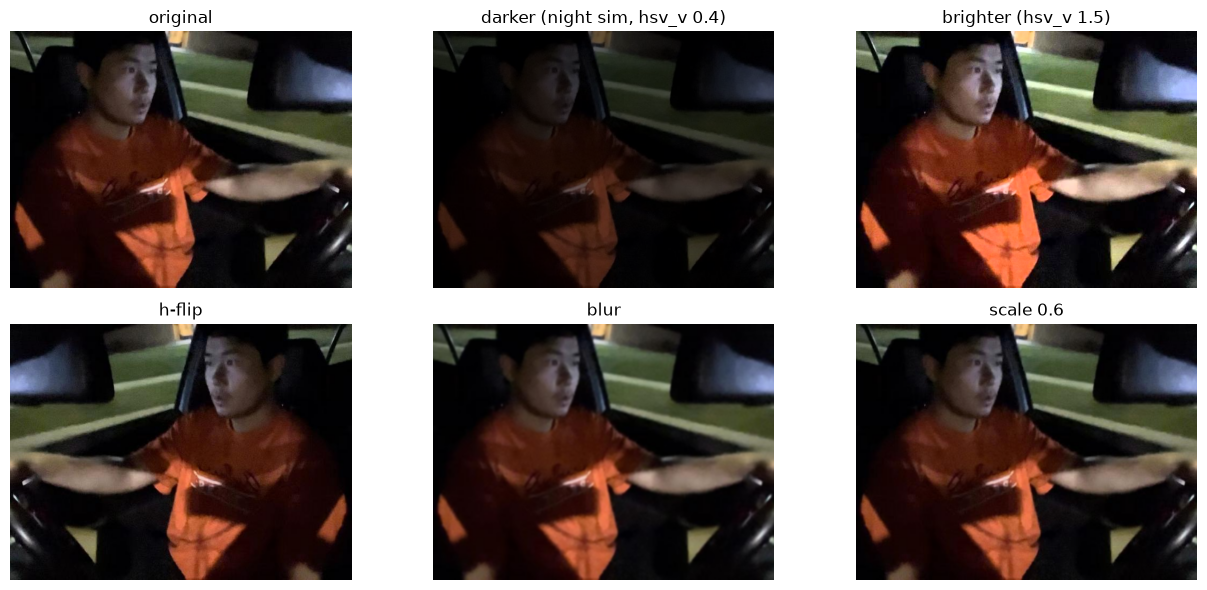

Training augmentation: hsv_v=0.6, hsv_s=0.5, fliplr=0.5, scale=0.5, translate=0.1, degrees=5, mosaic=1.0


In [3]:
import cv2, numpy as np
sample = sorted(glob.glob(f"{DS}/train/images/*.jpg"))[0]
img = cv2.cvtColor(cv2.imread(sample), cv2.COLOR_BGR2RGB)
def hsv_v(im,f):
    h=cv2.cvtColor(im,cv2.COLOR_RGB2HSV).astype(float); h[...,2]=np.clip(h[...,2]*f,0,255); return cv2.cvtColor(h.astype(np.uint8),cv2.COLOR_HSV2RGB)
augs={"original":img,"darker (night sim, hsv_v 0.4)":hsv_v(img,0.4),"brighter (hsv_v 1.5)":hsv_v(img,1.5),
      "h-flip":img[:,::-1],"blur":cv2.GaussianBlur(img,(7,7),0),"scale 0.6":cv2.resize(cv2.resize(img,None,fx=.6,fy=.6),(img.shape[1],img.shape[0]))}
fig,ax=plt.subplots(2,3,figsize=(13,6))
for a,(t,im) in zip(ax.ravel(),augs.items()): a.imshow(im); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()
print("Training augmentation: hsv_v=0.6, hsv_s=0.5, fliplr=0.5, scale=0.5, translate=0.1, degrees=5, mosaic=1.0")

**References (datasets).**
- iPylot. *Distracted Driving* dataset. Roboflow Universe.
  https://universe.roboflow.com/ipylot-project/distracted-driving-v2wk5
- M. J. Rahman. *Driver Detection* dataset. Roboflow Universe.
- TEKNOFEST competition footage (provided clips) — used for qualitative validation.